In [16]:
import sys
sys.path.append('../')
import time

import h5py
import numpy as np
from matplotlib import pyplot as plt

import epics
from siriuspy.devices import CAXCtrl
from caxscripts.h5file import HDF5File

In [17]:
cax = CAXCtrl()

In [35]:
def initialize_hdf5(fname, d):
    
    with h5py.File(fname, 'w') as f:
        f.attrs['begin time'] = time.strftime("%Y-%m-%d %H:%M:%S", time.localtime())
        keys = list(d.keys())
        for key in keys:
            f.attrs[key] = d[key]


def append_dataset_hdf5(fname, data, tag, t0, position):
    
    with h5py.File(fname, 'a') as f:
        dset = f.create_dataset('step_{0:03d}'.format(tag), data=data, compression="gzip")
        dset.attrs['z'] = position
        dset.attrs['ellapsed time (s)'] = round(time.time() - t0, 3)


def read_caustic(fname='test.h5'):
    
    f = h5py.File(fname, 'r')
    
    d = dict()
    
    d['zstart'] = f.attrs['zstart'] 
    d['zfin'] = f.attrs['zfin'] 
    d['zstep'] = f.attrs['zstep']
    d['positions'] = f.attrs['positions']
    d['nz'] = len(d['positions'])

    img0 = np.array(f['step_{0:03d}'.format(0)])
    
    d['ny'], d['nx'] = img0.shape

    caustic3D = np.zeros((d['nz'], d['ny'], d['nx']))
    
    for i in range(d['nz']):
        dataset = 'step_{0:03d}'.format(i)
        caustic3D[i] = np.array(f[dataset])

    f.close()

    return caustic3D, d


pv_ny = "CAX:B:BASLER01:image1:ArraySize0_RBV"
pv_nx = "CAX:B:BASLER01:image1:ArraySize1_RBV"
pv_img = "CAX:B:BASLER01:image1:ArrayData"

pv_screen_pos_sp = "CAX:B:PP01:E.VAL"
pv_screen_pos_rbv = "CAX:B:PP01:E.RBV"


ny = epics.caget(pv_ny)
nx = epics.caget(pv_nx)


# Functions

Useful functions for the scan

In [ ]:
def move_screen(z_pos):
    epics.caput(pv_screen_pos_sp, z_pos)

def move_robust_screen(z_pos):

    move_screen(z_pos)

    while(np.abs(epics.caget(pv_screen_pos_rbv) - z_pos) >= 0.2):
        time.sleep(0.5)

    time.sleep(0.5)

In [3]:
fname = 'caustic_scan_20250717_01.h5'

d = dict()

d['zstart'] = 560
d['zfin'] = 140
d['zstep'] = -20

# d['zstart'] = 560
# d['zfin'] = 540
# d['zstep'] = -10

d['positions'] = np.arange(d['zstart'], d['zfin'] + d['zstep'], d['zstep'])

initialize_hdf5(fname, d)

print(d['positions'])


[560 540 520 500 480 460 440 420 400 380 360 340 320 300 280 260 240 220
 200 180 160 140]


# Scan

## Parameters

In [15]:
pos_start = 560
pos_end   = 140
pos_step  = -20

positions = np.arange(pos_start,pos_end+pos_step,pos_step)

# Execution

In [ ]:
# top0, bottom0, left0, right0 = current_position()

# with open('initial_position.txt','w') as f:
#     f.write(f'top: {top0}\n')
#     f.write(f'bottom: {bottom0}\n')
#     f.write(f'left: {left0}\n')
#     f.write(f'right: {right0}')

# print(top0, bottom0, left0, right0)

Initialize file

In [ ]:
filename = 'caustic_scan_20250717_01.h5'
filedir = "/home/ids/data/2025-07-17-Caustic"
file = HDF5File(filename=filename,filedir=filedir)

file.save_metadata(metadata_dict={
    'position': cax.dvf_B1.z_pos
})

Loop

In [ ]:

t0 = time.time()

for i, pos in enumerate(positions):

    move_robust_screen(z_pos=pos)

    screen_pos = cax.dvf_B1.z_pos #epics.caget(pv_screen_pos_rbv)
    print('finished movement {0}/{1}: pos={2:.1f} mm'.format(i+1, len(positions), pos), end='\r')

    img = cax.dvf_B1.image

    pos_dict = {'position': cax.dvf_B1.z_pos}

    file.save_dataset(dsetname=f'scan-{i:03d}',dsetdata=img,dsetmetadata=pos_dict)
    
    # append_dataset_hdf5(fname, img, i, t0, screen_pos)

print('finished scan!')



finished scan!ent 22/22: pos=140.0 mm


In [36]:
caustic, d = read_caustic(fname)

cx = np.sum(caustic, axis=1)[::-1].T
cy = np.sum(caustic, axis=2)[::-1].T

extx = [d['zfin'], d['zstart'], 0, d['nx']]
exty = [d['zfin'], d['zstart'], 0, d['ny']]


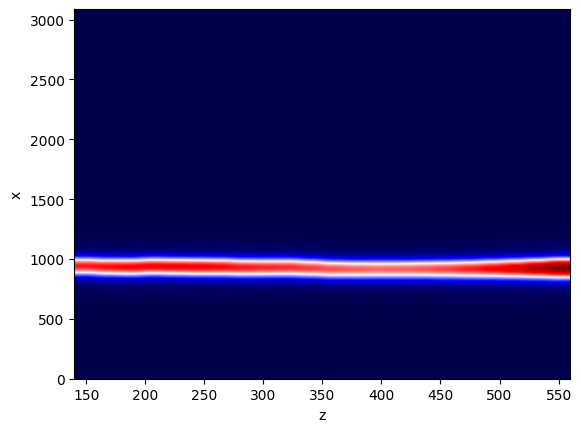

In [30]:
plt.figure()
plt.imshow(cx, origin='lower', aspect='auto', extent=extx, cmap='seismic')
plt.xlabel('z')
plt.ylabel('x')
plt.show()


In [19]:
def fwhm(data):
    mask = data > 0.5*np.max(data)
    return np.sum(mask)

In [37]:
fwhm(cx[:,10])

149

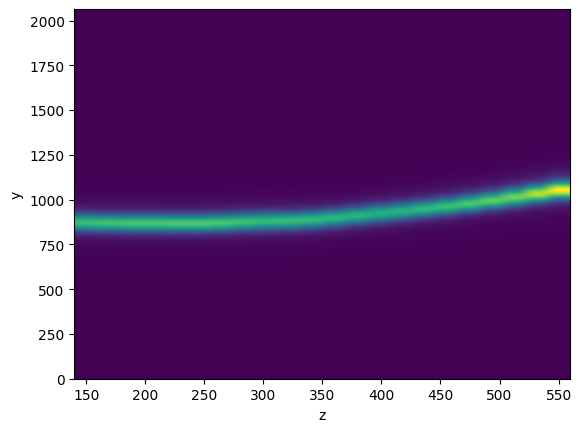

In [7]:
plt.figure()
plt.imshow(cy, origin='lower', aspect='auto', extent=exty)
plt.xlabel('z')
plt.ylabel('y')
plt.show()

In [27]:
fwhmsx = []
fwhmsy = []

for iz in np.arange(len(positions)):
    fwhmsx.append(fwhm(cx[:,iz]))
    fwhmsy.append(fwhm(cy[:,iz]))

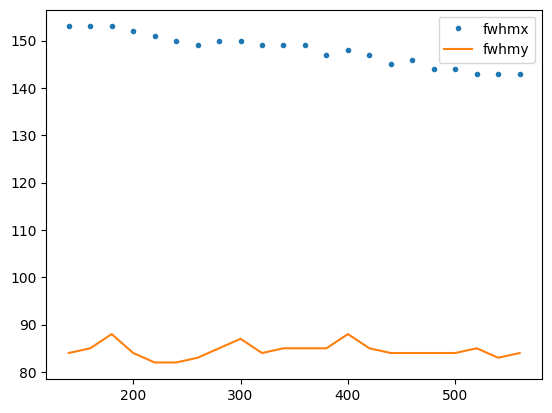

In [31]:
plt.plot(positions,fwhmsx,'.',label='fwhmx')
plt.plot(positions,fwhmsy,label='fwhmy')
plt.legend()
plt.show()

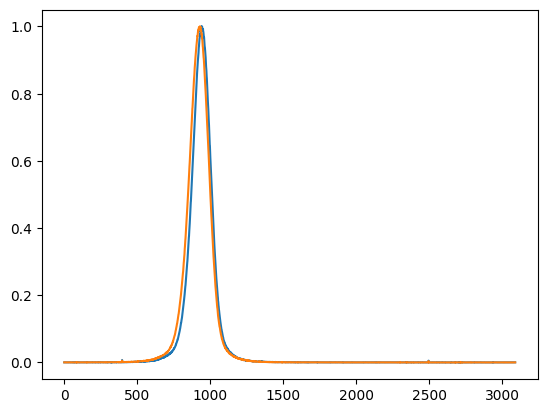

In [34]:
plt.plot(cx[:,0]/np.max(cx[:,0]))
plt.plot(cx[:,-1]/np.max(cx[:,-1]))
plt.show()